In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from jax.lax import slice as jax_slice
from jax.scipy.signal import fftconvolve

from aim_resolve import Observation, SignalSpace, SignalModel, plot_arrays, check_type, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


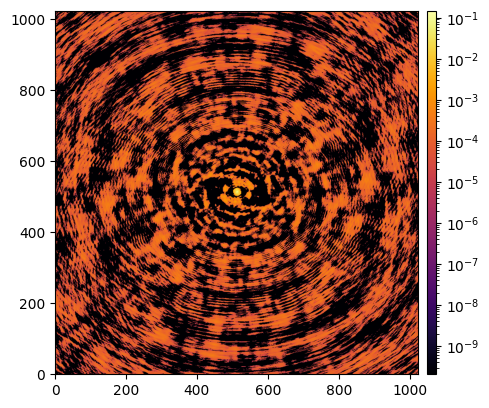

In [2]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100)

In [221]:
from jax.numpy.fft import fftn, ifftn
from jax.lax import dynamic_slice
from jax.scipy.signal import fftconvolve


def build_slicer(kernel, shape):
    k0, k1 = kernel.shape
    return lambda x: dynamic_slice(x, (k0//2, k1//2), shape)


def scipy_fftconvolve(kernel, shape, dvol=1.):
    slicer = build_slicer(kernel, shape)
    return lambda x: slicer(fftconvolve(x, kernel * dvol, mode='full'))


def build_fft_kernel(kernel, shape, dvol=1.):
    return jnp.fft.fftn(kernel, shape) * dvol


def fast_fftconvolve(kernel, shape, dvol=1.):
    if all(k >= 2*s for k, s in zip(kernel.shape, shape)):
        fft_shape = kernel.shape
    else:
        fft_shape = tuple(k+s-1 for k,s in zip(kernel.shape, shape))

    fft_kernel = build_fft_kernel(kernel, fft_shape, dvol)

    slicer = build_slicer(kernel, shape)

    return lambda x: slicer(ifftn(fft_kernel * fftn(x, fft_shape)).real)


def split_kernel(kernel, factors):
    if factors[0] != 1:
        raise ValueError('First factor must be 1')

    kshape = kernel.shape
    fshape = tuple(k // max(factors) for k in kshape)

    skernel = np.zeros((len(factors),) +  fshape)
    for i,f in enumerate(factors):
        ker = np.zeros_like(kernel)
        if i == 0:
            slc_in = (slice(0, 0), slice(0, 0))
        else:
            slc_in = slc_out

        slc_out = tuple(slice(ks//2 - f*fs//2, ks//2 + f*fs//2) for ks, fs in zip(kshape, fshape))

        ker[slc_out] = kernel[slc_out]
        ker[slc_in] = 0
        skernel[i] = downsample(ker[slc_out], f)

    return skernel


# def split_fftconvolve(kernel, shape, dvol=1., fmax=2):
#     factors = np.array([f for f in [1,2,4,8] if f <= fmax])
#     kernels = split_kernel(kernel, factors)
#     shapes = np.array(shape) * 1//factors[:,None]
#     split_funs = [fast_fftconvolve(kernels[i], shapes[i], dvol*(f**2)) for i,f in enumerate(factors)]

#     def fun(x):
#         res = jnp.zeros_like(x)
#         for i,f in enumerate(factors):
#             xi = downsample(x, f)
#             ri = split_funs[i](xi)
#             res += upsample(ri, f)
#         return res
    
#     return fun


def split_fftconvolve(kernel, shape, dvol=1., fmax=2):
    factors = np.array([f for f in [1,2,4,8] if f <= fmax])
    kernels = split_kernel(kernel, factors)
    shapes = np.array(shape) * 1//factors[:,None]

    fft_shapes, fft_kernels, slicers = [], [], []
    for i,f in enumerate(factors):
        if all(k >= 2*s for k, s in zip(kernels[i].shape, shapes[i])):
            fft_shape = kernels[i].shape
        else:
            fft_shape = tuple(k+s-1 for k,s in zip(kernels[i].shape, shapes[i]))

        fft_shapes.append(fft_shape)
        fft_kernels.append(build_fft_kernel(kernels[i], fft_shape, dvol*(f**2)))
        for f in fft_kernels:
            print(f.shape)
        slicers.append(build_slicer(kernels[i], shapes[i]))

    def fun(x):
        res = jnp.zeros_like(x)
        for i,f in enumerate(factors):
            xi = downsample(x, f)
            ri = slicers[i](ifftn(fft_kernels[i] * fftn(xi, fft_shapes[i])).real)
            res += upsample(ri, f)
        return res
    
    return fun


def downsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')

In [222]:
class ScipyResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return scipy_fftconvolve(self.kernel, self.shape, self.dvol)(self.model(x))
    


class MyResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.dvol = model.space.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return fast_fftconvolve(self.kernel, self.shape, self.dvol)(self.model(x))



class MultiResResponse(jft.Model):
    def __init__(self, model, kernel, fmax=2):
        self.model = model
        self.kernel = kernel
        self.shape = model.space.shape
        self.dvol = model.space.dis.prod()
        self.fmax = fmax
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        return split_fftconvolve(self.kernel, self.shape, self.dvol, self.fmax)(self.model(x))
        


class MultiKernelResponse(jft.Model):
    def __init__(self, model, kernel, fmax=2):
        self.model = model
        self.factors = np.array([f for f in [1,2,4,8] if f <= fmax])
        kernels = split_kernel(kernel, self.factors)
        shapes = np.array(model.space.shape) * 1//self.factors[:,None]
        dvol = model.space.dis.prod()
        self.split_funs = [fast_fftconvolve(kernels[i], shapes[i], dvol*(f**2)) for i,f in enumerate(self.factors)]
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        x = self.model(x)
        res = jnp.zeros_like(x)
        for i,f in enumerate(self.factors):
            xi = downsample(x, f)
            ri = self.split_funs[i](xi)
            res += upsample(ri, f)
        return res

(767, 767)
(767, 767)
(511, 511)
(767, 767)
(511, 511)
(256, 256)


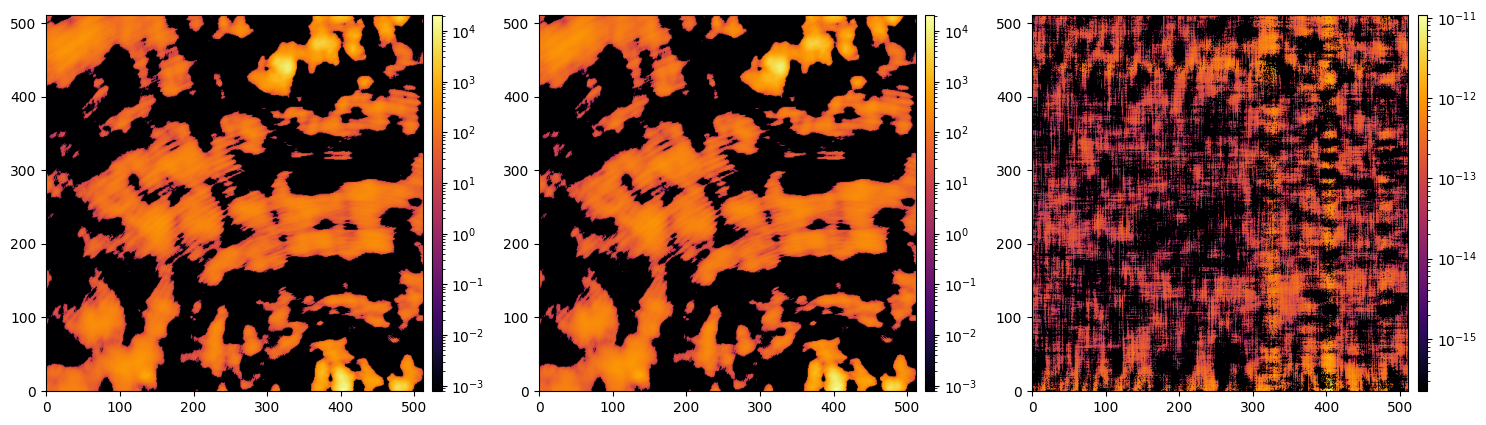

(767, 767)
(767, 767)
(511, 511)
(767, 767)
(511, 511)
(256, 256)
(767, 767)
(767, 767)
(511, 511)
(767, 767)
(511, 511)
(256, 256)


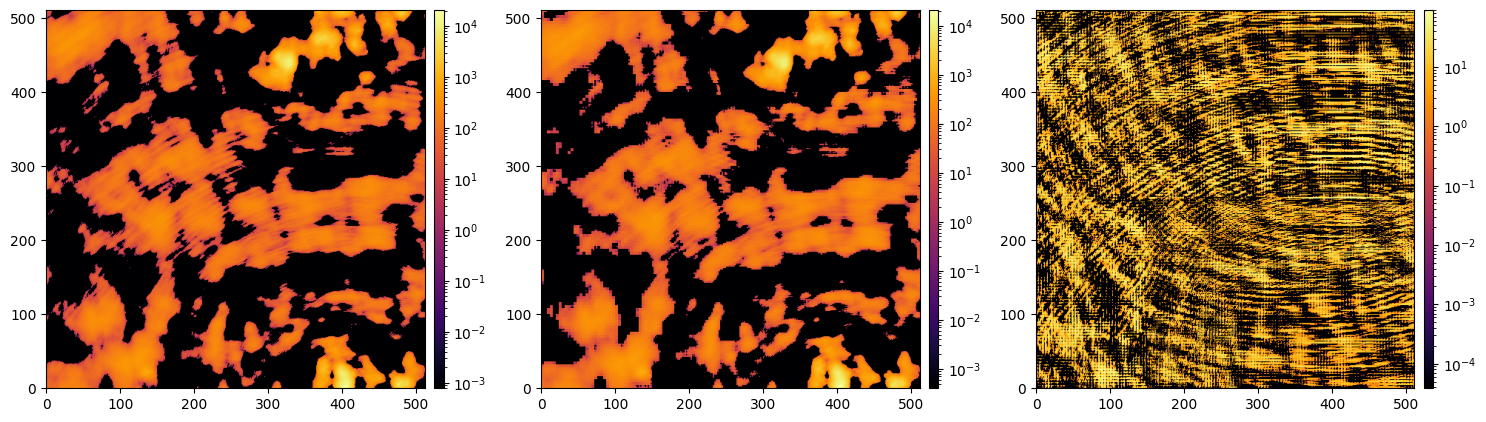

(767, 767)
(767, 767)
(511, 511)
(767, 767)
(511, 511)
(256, 256)


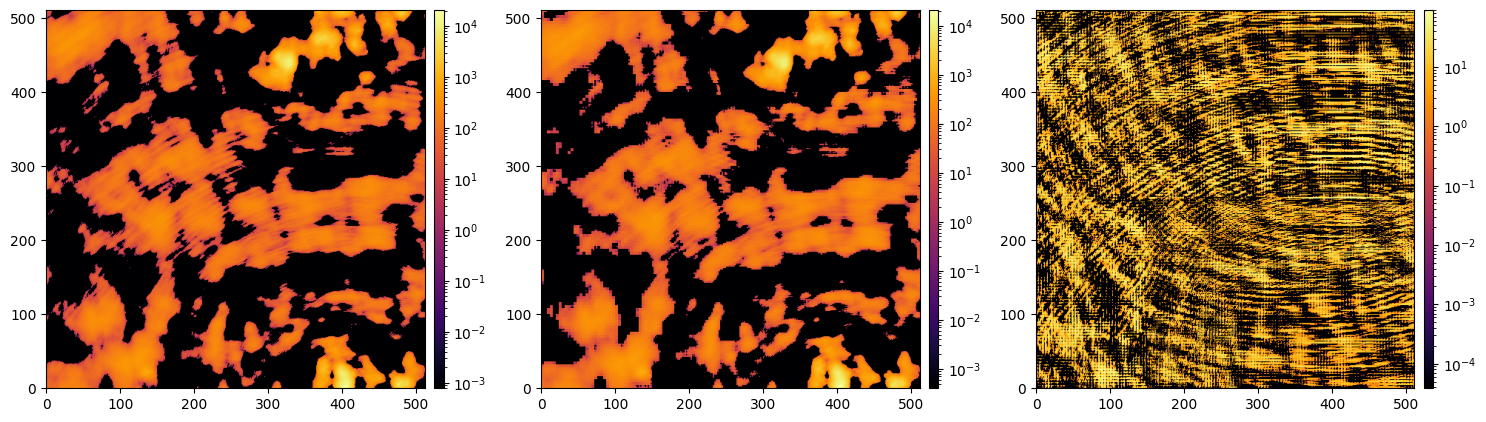

In [223]:
fmax = 4

signal = SignalModel.build(
    prefix='sig',
    space=dict(
        shape=(512, 512),
        fov=('2deg', '2deg'),
    ),
    i0=dict(
        offset_mean=12,
        offset_std=(1,1),
        fluctuations=(5,1),
        loglogavgslope=(-2,0.5),
        flexibility=(1.2,0.4),
        asperity=(0.2,0.2),
    ),
)


sp_response = ScipyResponse(signal, kernel)

my_response = MyResponse(signal, kernel)

mk_response = MultiKernelResponse(signal, kernel, fmax)

mr_response = MultiResResponse(signal, kernel, fmax)



key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

plot_arrays([sp_response(prior_xi), my_response(prior_xi), sp_response(prior_xi) - my_response(prior_xi)], rows=1, norm='log')
plot_arrays([my_response(prior_xi), mr_response(prior_xi), mr_response(prior_xi) - my_response(prior_xi)], rows=1, norm='log')
plot_arrays([my_response(prior_xi), mk_response(prior_xi), mr_response(prior_xi) - my_response(prior_xi)], rows=1, norm='log')

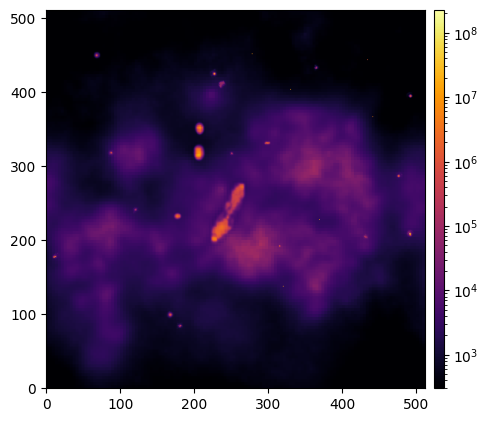

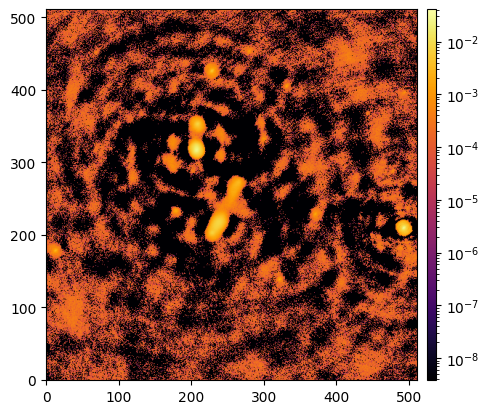

In [25]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_o0 = optim_cfg.instantiate_sec('sky_o0.3')
sky_o1 = optim_cfg.instantiate_sec('sky_o1.3')
sky_o2 = optim_cfg.instantiate_sec('sky_o2.3')
sky_t0 = optim_cfg.instantiate_sec('sky_t0.3')
sky_p0 = optim_cfg.instantiate_sec('sky_p0.3')



with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = upsample(downsample(samples.mean(sky_bg), fmax), fmax)
rec_o0 = map_signal(samples.mean(sky_o0), sky_o0.space, sky_bg.space)
rec_o1 = map_signal(samples.mean(sky_o1), sky_o1.space, sky_bg.space)
rec_o2 = map_signal(samples.mean(sky_o2), sky_o2.space, sky_bg.space)
rec_t0 = samples.mean(sky_t0)
rec_p0 = samples.mean(sky_p0)

rec = rec_bg + rec_o0 + rec_o1 + rec_o2 + rec_t0 + rec_p0
# rec = downsample(rec, 2)


def generate_data(rec, kernel, space, n_std=1e-4):
    truth = fftconvolve(rec, kernel, mode='same') * space.dis.prod()
    noise = n_std * jax.random.normal(key, truth.shape)
    data = truth + noise
    return data


data = generate_data(rec, kernel, space)


plot_arrays(rec, norm='log', vmin=3e2, vmax=rec.max(), dpi=100)
plot_arrays(data, rows=1, norm='log')


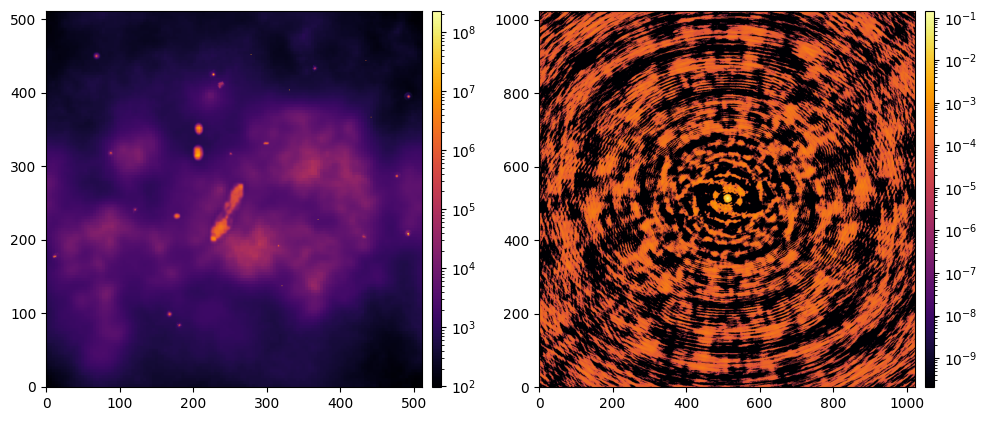

(512, 512) (1024, 1024)


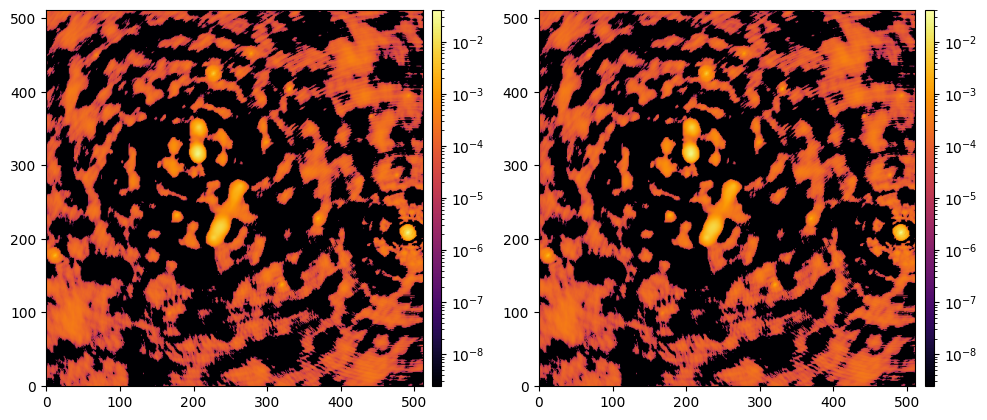

res_scp == res_new: True


In [ ]:
from jax.numpy.fft import fftn, ifftn
from jax.lax import dynamic_slice


def build_fft_kernel(kernel, shape, dvol=1.):
    return jnp.fft.fftn(kernel, shape) * dvol


def build_slicer(kernel, shape):
    k0, k1 = kernel.shape
    return lambda x: dynamic_slice(x, (k0//2, k1//2), shape)


def apply_fftconvolve(kernel, shape, dvol=1.):
    if all(k >= 2*s for k, s in zip(kernel.shape, shape)):
        fft_shape = kernel.shape
    else:
        fft_shape = tuple(k+s-1 for k,s in zip(kernel.shape, shape))

    fft_kernel = build_fft_kernel(kernel, fft_shape, dvol)

    slicer = build_slicer(kernel, shape)

    return lambda x: slicer(ifftn(fft_kernel * fftn(x, fft_shape)).real)

s = 256
k = 512

val = rec.copy()[256-s:256+s, 256-s:256+s]
ker = kernel.copy()[512-k:512+k, 512-k:512+k]
plot_arrays([val, ker], norm='log', rows=1)
print(val.shape, ker.shape)

res_scp = fftconvolve(val, ker, mode='full') * space.dis.prod()
res_scp = jax_slice(res_scp, (ker.shape[0]//2, ker.shape[1]//2), (ker.shape[0]//2 + val.shape[0], ker.shape[1]//2 + val.shape[1]))

res_new = apply_fftconvolve(ker, val.shape, space.dis.prod())(val)
plot_arrays([res_scp, res_new], rows=1, norm='log')

print('res_scp == res_new:', np.allclose(res_scp, res_new, atol=1e-15))

fshape: (640, 640)


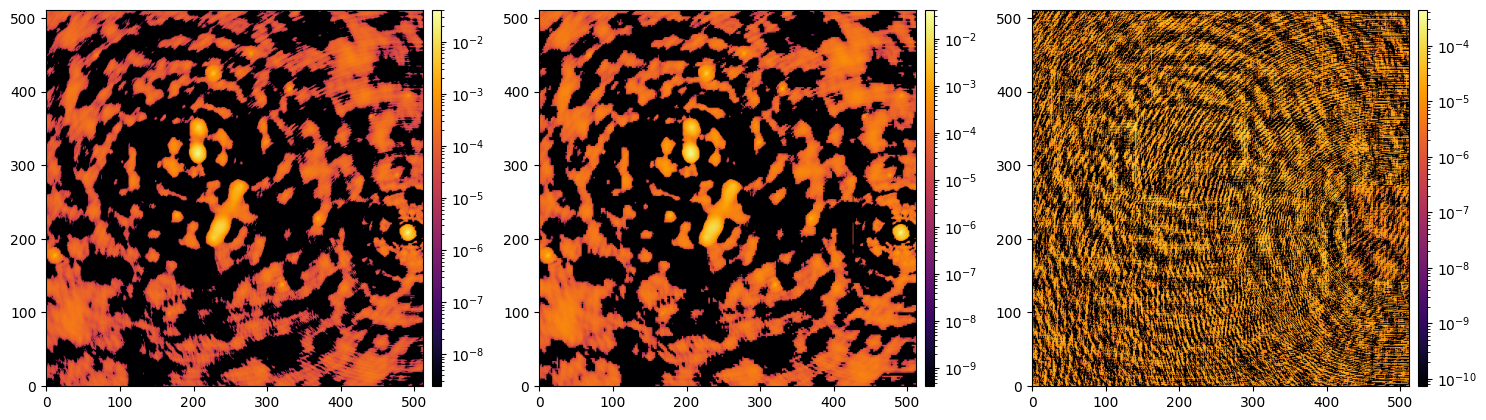

In [234]:
from jax import vmap
from jax.numpy.fft import fftn, ifftn
from jax.lax import dynamic_slice
from jax.scipy.signal import fftconvolve



def downsample(array, factor):
    return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    

def upsample(array, factor):
    return array.repeat(factor, axis=0).repeat(factor, axis=1)


def build_fft_kernel(kernel, shape, dvol=1.):
    return jnp.fft.fftn(kernel, shape) * dvol


def split2_kernel(kernel, shape, size, dvol=1.):
    fshape = tuple(s+size for s in shape)
    print('fshape:', fshape)

    fkernel = np.zeros((2,) +  fshape, dtype='complex128')
    for f in range(1, 3):
        ker = np.zeros_like(kernel)
        if f == 1:
            slc_in = (slice(0, 0), slice(0, 0))
            slc_out = tuple(slice(k//2 - size//2, k//2 + size//2) for k in kernel.shape)
        else:
            slc_in = slc_out
            slc_out = tuple(slice(0, k) for k in kernel.shape)

        ker[slc_out] = kernel[slc_out]
        ker[slc_in] = 0
        
        ker = downsample(ker[slc_out], f)
        fker = build_fft_kernel(ker, fshape, dvol * (f**2))
        fkernel[f-1] = fker

    return fkernel


def build_padder(in_shape, out_shape):
    p0, p1 = [(s - a) for s,a in zip(out_shape, in_shape)]
    return lambda x: jnp.pad(x, ((0, p0), (0, p1)))


def build_slicer(start_indices, out_shape):
    s0, s1 = start_indices
    return lambda x: dynamic_slice(x, (s0, s1), out_shape)


def scipy_fftconvolve(kernel, shape, dvol=1.):
    slicer = build_slicer(tuple(k//2 for k in kernel.shape), shape)
    return lambda x: slicer(fftconvolve(x, kernel * dvol, mode='full'))


def split2_fftconvolve(kernel, shape, size, dvol=1.):
    fft_kernels = split2_kernel(kernel, shape, size, dvol)

    fft_shape = fft_kernels.shape[1:]

    pad1 = build_padder(shape, fft_shape)
    pad2 = build_padder(tuple(s//2 for s in shape), fft_shape)

    slc1 = build_slicer((size//2,) * 2, shape)
    slc2 = build_slicer(tuple(k//4 for k in kernel.shape), tuple(s//2 for s in shape))

    def fun(x):
        x1 = pad1(x)
        x2 = pad2(downsample(x, 2))
        c1 = ifftn(fft_kernels[0] * fftn(x1)).real
        c2 = ifftn(fft_kernels[1] * fftn(x2)).real
        r1 = slc1(c1)
        r2 = upsample(slc2(c2), 2)
        return r1 + r2

    return fun



size = 128

res = split2_fftconvolve(kernel, rec.shape, size, space.dis.prod())(rec)

res0 = scipy_fftconvolve(kernel, rec.shape, space.dis.prod())(rec)

plot_arrays([res0, res, res-res0], norm='log', rows=1)

OPTIMIZE_KL: Starting 0001


fshape: (576, 576)
s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.3863e+05
OPTIMIZE_KL: #(KL minimization steps) 50
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:   +0.022±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
sig i0 asperity         :: 'reduced χ²: 6.2e-05±     0.0, avg:  +0.0079±     0.0, #dof:      1'
sig i0 flexibility      :: 'reduced χ²:  0.0058±     0.0, avg:   +0.076±     0.0, #dof:      1'
sig i0 fluctuations     :: 'reduced χ²:     4.9±     0.0, avg:     +2.2±     0.0, #dof:      1'
sig i0 loglogavgslope   :: 'reduced χ²:    0.12±     0.0, avg:    +0.35±     0.0, #dof:      1'
sig i0 spectrum         :: 'reduced χ²: 0.00012±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
sig i0 xi               :: 'reduced χ²: 0.00024±     0.0, avg: +4.8e-07±     0.0, #dof: 262144'
sig i0 zeromode         :: 'reduced χ²:     1.9±     0.0, avg:     +1.4±     0.0, #dof:      1'




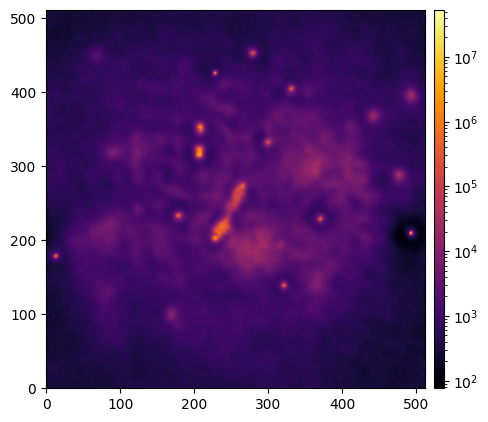

In [236]:
class Split2Response(jft.Model):
    def __init__(self, model, kernel, size):
        self.model = model

        shape = model.space.shape
        dvol = model.space.dis.prod()
        self.fft_kernels = split2_kernel(kernel, shape, size, dvol)

        fft_shape = self.fft_kernels.shape[1:]

        self.pad1 = build_padder(shape, fft_shape)
        self.pad2 = build_padder(tuple(s//2 for s in shape), fft_shape)
        self.slc1 = build_slicer((size//2,) * 2, shape)
        self.slc2 = build_slicer(tuple(k//4 for k in kernel.shape), tuple(s//2 for s in shape))

        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        x = self.model(x)
        x1 = self.pad1(x)
        x2 = self.pad2(downsample(x, 2))
        c1 = ifftn(self.fft_kernels[0] * fftn(x1)).real
        c2 = ifftn(self.fft_kernels[1] * fftn(x2)).real
        r1 = self.slc1(c1)
        r2 = upsample(self.slc2(c2), 2)
        return r1 + r2
    

s2_response = Split2Response(signal, kernel, 64)


lh_dct = dict(
    data = data,
    model = s2_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

hr_samples, _ = optimize_kl(
    likelihood=lh_dct,
    key=4,
    n_total_iterations=1,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=50,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.3173e+05
OPTIMIZE_KL: #(KL minimization steps) 50
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.015±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
sig i0 asperity         :: 'reduced χ²: 2.5e-05±     0.0, avg:   +0.005±     0.0, #dof:      1'
sig i0 flexibility      :: 'reduced χ²:  0.0036±     0.0, avg:    +0.06±     0.0, #dof:      1'
sig i0 fluctuations     :: 'reduced χ²:     5.5±     0.0, avg:     +2.3±     0.0, #dof:      1'
sig i0 loglogavgslope   :: 'reduced χ²:    0.17±     0.0, avg:    +0.41±     0.0, #dof:      1'
sig i0 spectrum         :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
sig i0 xi               :: 'reduced χ²: 0.00025±     0.0, avg: +9.5e-07±     0.0, #dof: 262144'
sig i0 zeromode         :: 'reduced χ²:     2.0±     0.0, avg:     +1.4±     0.0, #dof:      1'




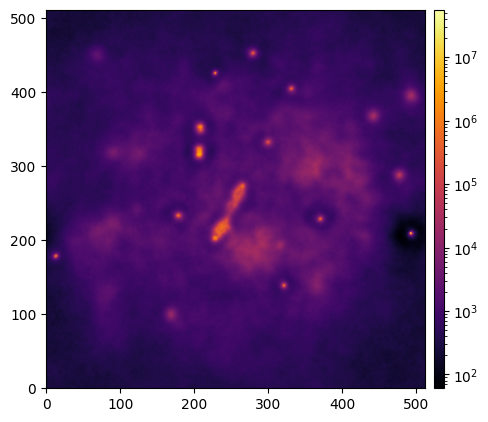

In [224]:
lh_dct = dict(
    data = data,
    model = my_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

mk_samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=1,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=50,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+1.3204e+05
OPTIMIZE_KL: #(KL minimization steps) 50
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.015±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
sig i0 asperity         :: 'reduced χ²: 2.5e-05±     0.0, avg:   +0.005±     0.0, #dof:      1'
sig i0 flexibility      :: 'reduced χ²:  0.0035±     0.0, avg:   +0.059±     0.0, #dof:      1'
sig i0 fluctuations     :: 'reduced χ²:     5.2±     0.0, avg:     +2.3±     0.0, #dof:      1'
sig i0 loglogavgslope   :: 'reduced χ²:    0.15±     0.0, avg:    +0.39±     0.0, #dof:      1'
sig i0 spectrum         :: 'reduced χ²: 0.00011±     0.0, avg:  -0.0015±     0.0, #dof:  44048'
sig i0 xi               :: 'reduced χ²: 0.00025±     0.0, avg: +1.6e-06±     0.0, #dof: 262144'
sig i0 zeromode         :: 'reduced χ²:     2.0±     0.0, avg:     +1.4±     0.0, #dof:      1'




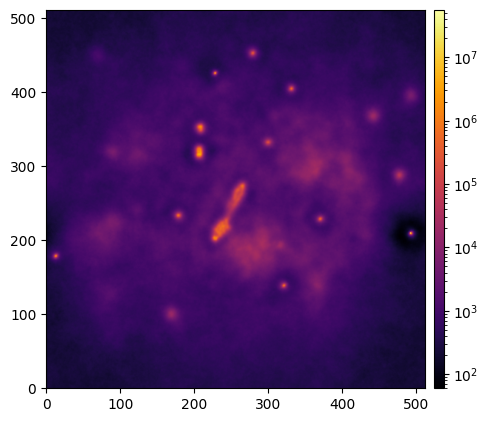

In [10]:
lh_dct = dict(
    data = data,
    model = sp_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

mk_samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=4,
    n_total_iterations=1,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=50,
            maxiter=50,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)